# Student Churn Analysis - Exploratory Data Analysis (EDA)

## Imports and Config

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)
palette = sns.color_palette("husl", 8)

## 1. Load Data and Data Preparation

In [3]:
df = pd.read_csv('../data/student_data_cleaned.csv')

df_students = df.sort_values(by=['student_id', 'term_number']).groupby('student_id').last().reset_index()

print(f"Total (semester-level) records: {len(df)}")
print(f"Unique students: {len(df_students)}")

Total (semester-level) records: 63233
Unique students: 12951


## 2.0 Baseline Distributions and Profiles

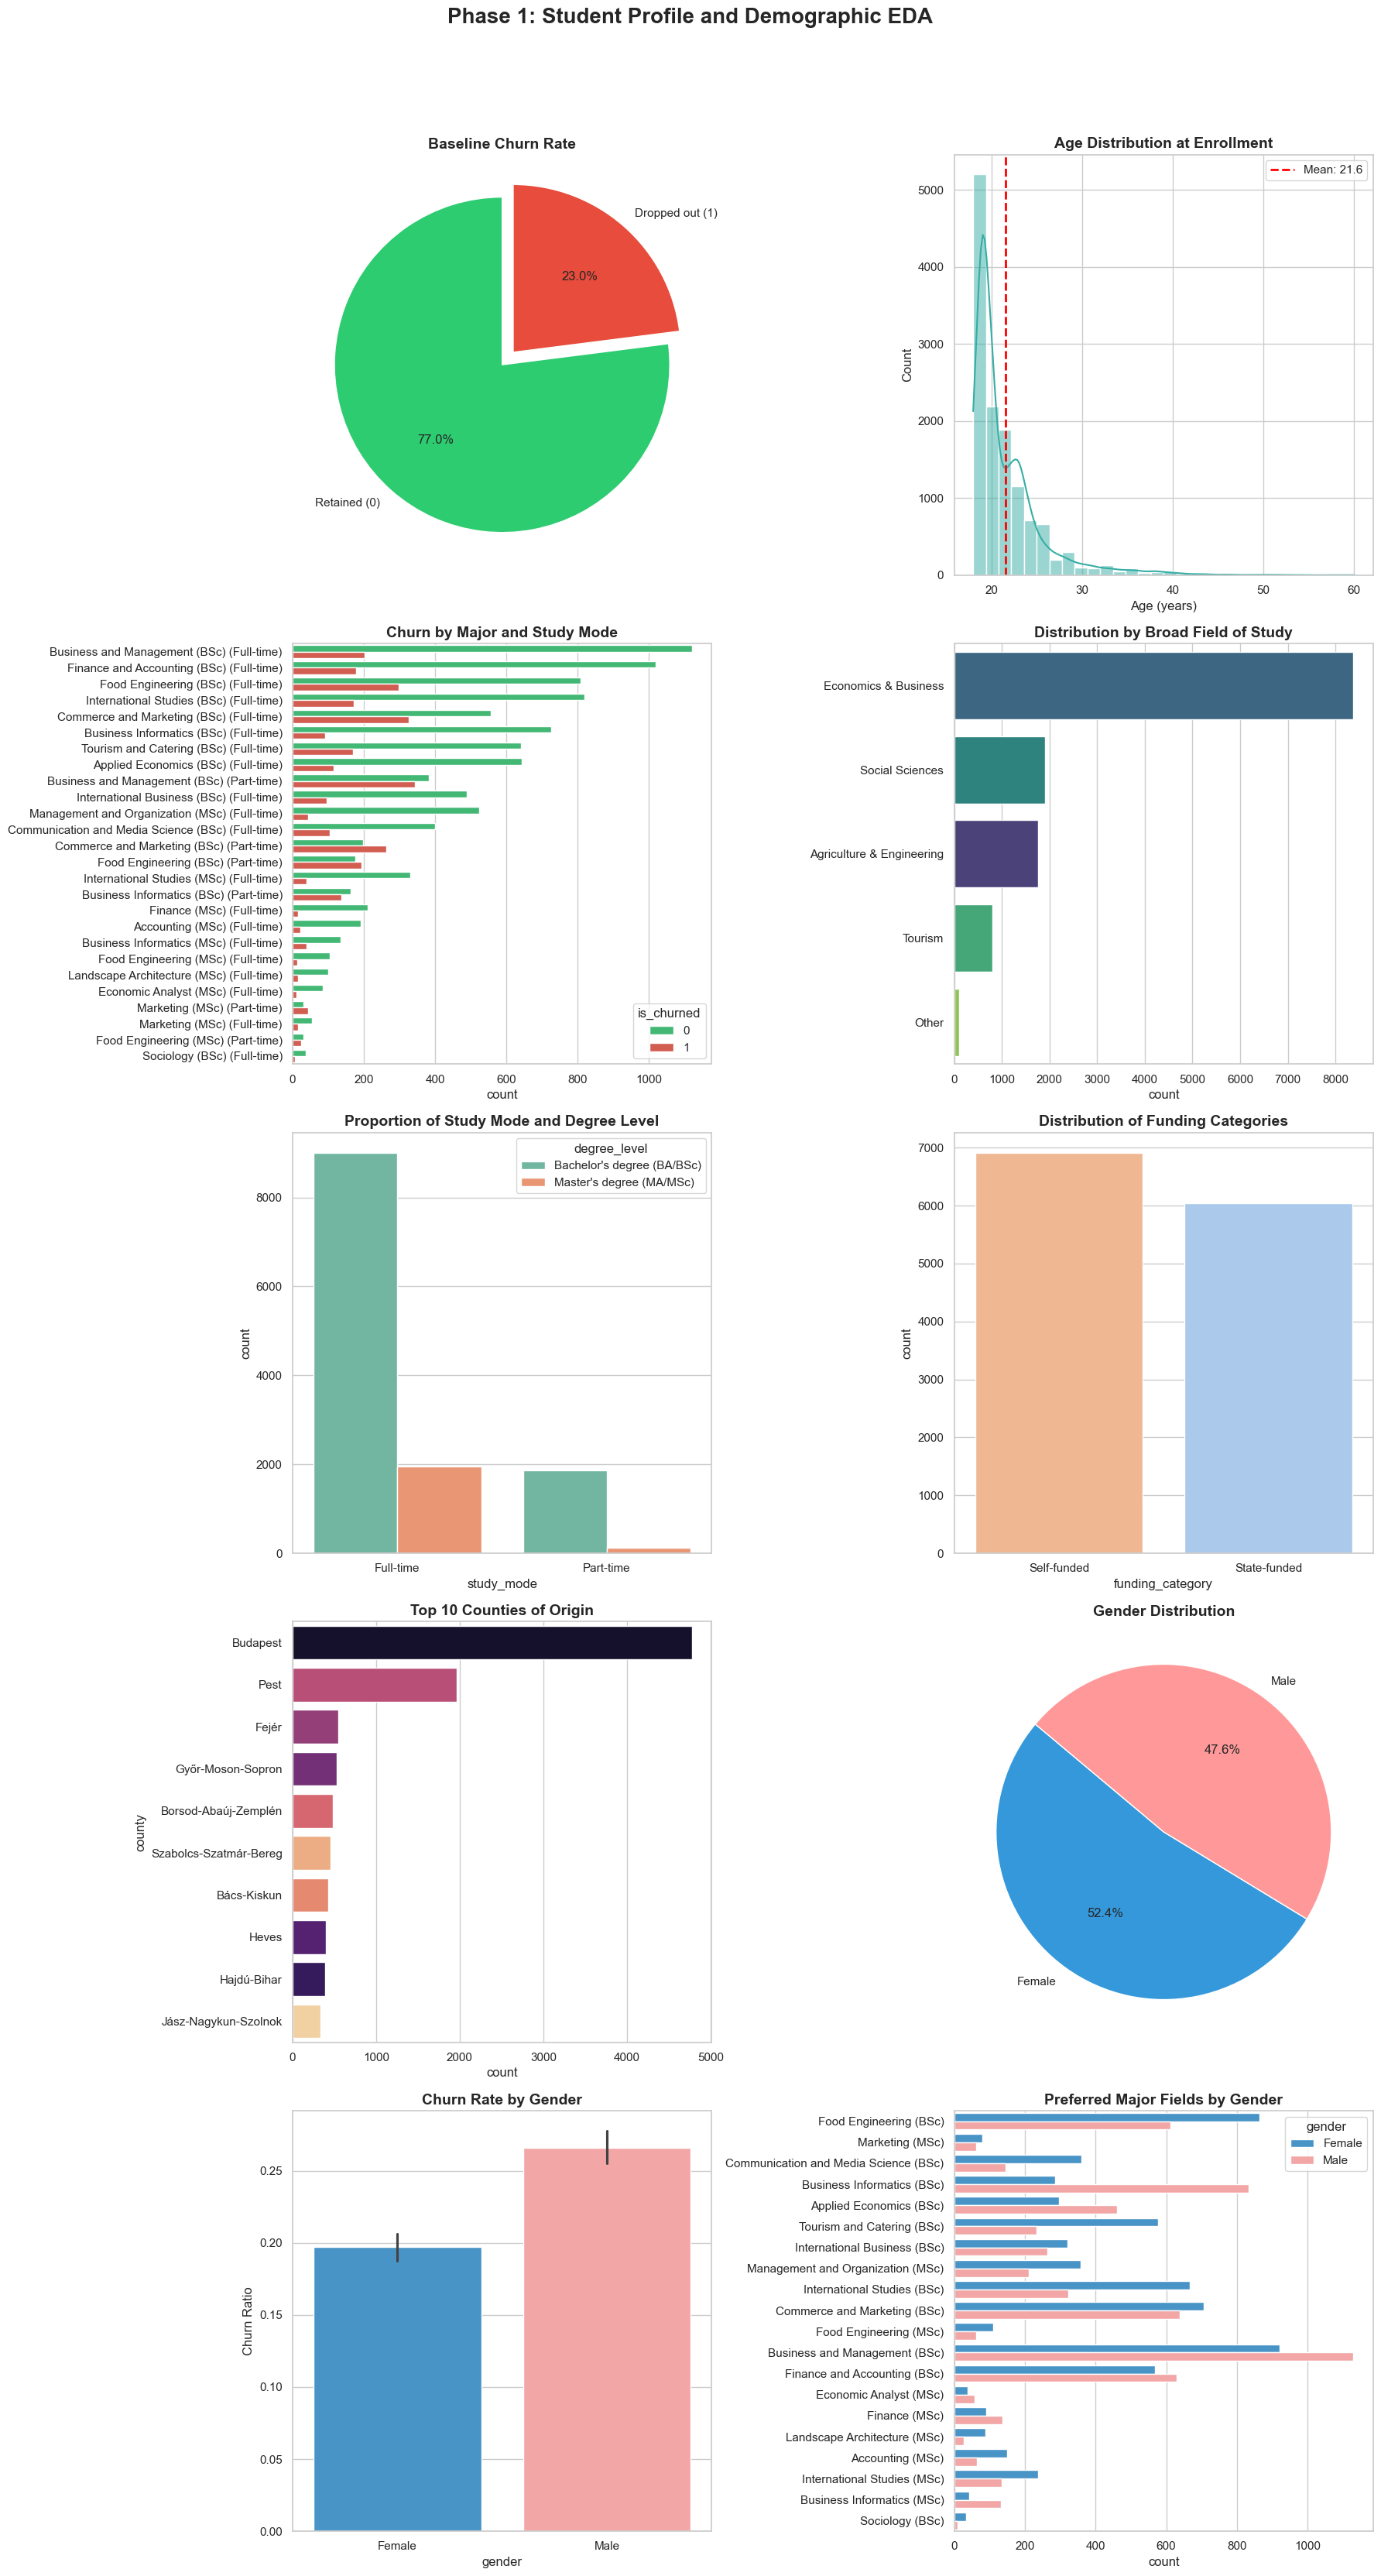

In [4]:
fig, axes = plt.subplots(5, 2, figsize=(18, 35))
fig.suptitle('Phase 1: Student Profile and Demographic EDA', fontsize=20, fontweight='bold', y=0.98)

# --- 1. Figure: Baseline Churn Rate ---
churn_counts = df_students['is_churned'].value_counts()
axes[0, 0].pie(churn_counts, labels=['Retained (0)', 'Dropped out (1)'], 
                 autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#e74c3c'], explode=(0, 0.1))
axes[0, 0].set_title('Baseline Churn Rate', fontsize=14, fontweight='bold')

# --- 2. Figure: Age at Enrollment ---
sns.histplot(data=df_students, x='age_at_enrollment', bins=30, kde=True, ax=axes[0, 1], color=palette[4])
axes[0, 1].set_title('Age Distribution at Enrollment', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Age (years)')
mean_age = df_students['age_at_enrollment'].mean()
axes[0, 1].axvline(mean_age, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_age:.1f}')
axes[0, 1].legend()

# --- 3. Figure: Major with Study Mode and Churn ---
df_students['major_with_mode'] = df_students['major_name_en'] + " (" + df_students['study_mode'] + ")"
sns.countplot(data=df_students, y='major_with_mode', hue='is_churned', 
              order=df_students['major_with_mode'].value_counts().index,
              palette=['#2ecc71', '#e74c3c'], ax=axes[1, 0])
axes[1, 0].set_title('Churn by Major and Study Mode', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('')

# --- 4. Figure: Fields of Study (Broad) ---
sns.countplot(data=df_students, y='major_field_broad', hue='major_field_broad',
              ax=axes[1, 1], order=df_students['major_field_broad'].value_counts().index, 
              palette='viridis', legend=False)
axes[1, 1].set_title('Distribution by Broad Field of Study', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('')

# --- 5. Figure: Study Mode and Degree Level ---
sns.countplot(data=df_students, x='study_mode', hue='degree_level', ax=axes[2, 0], palette='Set2')
axes[2, 0].set_title('Proportion of Study Mode and Degree Level', fontsize=14, fontweight='bold')

# --- 6. Figure: Funding Category ---
sns.countplot(data=df_students, x='funding_category', hue='funding_category',
              ax=axes[2, 1], palette='pastel', legend=False,
              order=df_students['funding_category'].value_counts().index)
axes[2, 1].set_title('Distribution of Funding Categories', fontsize=14, fontweight='bold')

# --- 7. Figure: Top Counties of Origin ---
top_counties = df_students['county'].value_counts().index[:10]
sns.countplot(data=df_students[df_students['county'].isin(top_counties)], y='county', 
              hue='county', ax=axes[3, 0], order=top_counties, palette='magma', legend=False)
axes[3, 0].set_title('Top 10 Counties of Origin', fontsize=14, fontweight='bold')

# --- 8. Gender Distribution ---
gender_counts = df_students['gender'].value_counts()
axes[3, 1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', 
                startangle=140, colors=['#3498db', '#ff9999'])
axes[3, 1].set_title('Gender Distribution', fontsize=14, fontweight='bold')

# --- 9. Churn Rate by Gender ---
sns.barplot(data=df_students, x='gender', y='is_churned', hue='gender', ax=axes[4, 0], palette=['#3498db', '#ff9999'], legend=False)
axes[4, 0].set_title('Churn Rate by Gender', fontsize=14, fontweight='bold')
axes[4, 0].set_ylabel('Churn Ratio')

# --- 10. Major Fields by Gender ---
sns.countplot(data=df_students, y='major_name_en', hue='gender', ax=axes[4, 1], palette=['#3498db', '#ff9999'])
axes[4, 1].set_title('Preferred Major Fields by Gender', fontsize=14, fontweight='bold')
axes[4, 1].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 2.1 Demographic Statistics Summary

In [5]:
print("--- PRESENTATION DATA AND STATISTICS ---\n")
total_students = len(df_students)
churned = int(df_students['is_churned'].sum())
retained = total_students - churned

print(f"1. CHURN RATE: Out of {total_students} students, {churned} dropped out ({churned/total_students:.1%}), and {retained} remained ({retained/total_students:.1%}).")
mean_age = df_students['age_at_enrollment'].mean()
print(f"2. AGE: Average age is {mean_age:.1f} years (Min: {df_students['age_at_enrollment'].min()}, Max: {df_students['age_at_enrollment'].max()}).")
major_churn = df_students.groupby('major_with_mode')['is_churned'].mean().sort_values(ascending=False)
print(f"3. MAJORS: Highest dropout major: {major_churn.index[0]} ({major_churn.values[0]:.1%}).")
mode_counts = df_students['study_mode'].value_counts()
print(f"5. PROGRAMS: {mode_counts.get('Full-time', 0)} Full-time vs {mode_counts.get('Part-time', 0)} Part-time.")
gender_churn = df_students.groupby('gender')['is_churned'].mean()
print(f"9. GENDER & CHURN: Male: {gender_churn.get('Male', 0):.1%}, Female: {gender_churn.get('Female', 0):.1%}.")

--- PRESENTATION DATA AND STATISTICS ---

1. CHURN RATE: Out of 12951 students, 2978 dropped out (23.0%), and 9973 remained (77.0%).
2. AGE: Average age is 21.6 years (Min: 18, Max: 60).
3. MAJORS: Highest dropout major: Marketing (MSc) (Part-time) (58.9%).
5. PROGRAMS: 10966 Full-time vs 1985 Part-time.
9. GENDER & CHURN: Male: 26.6%, Female: 19.7%.


## 3.0 Performance and Academic Risk Factors

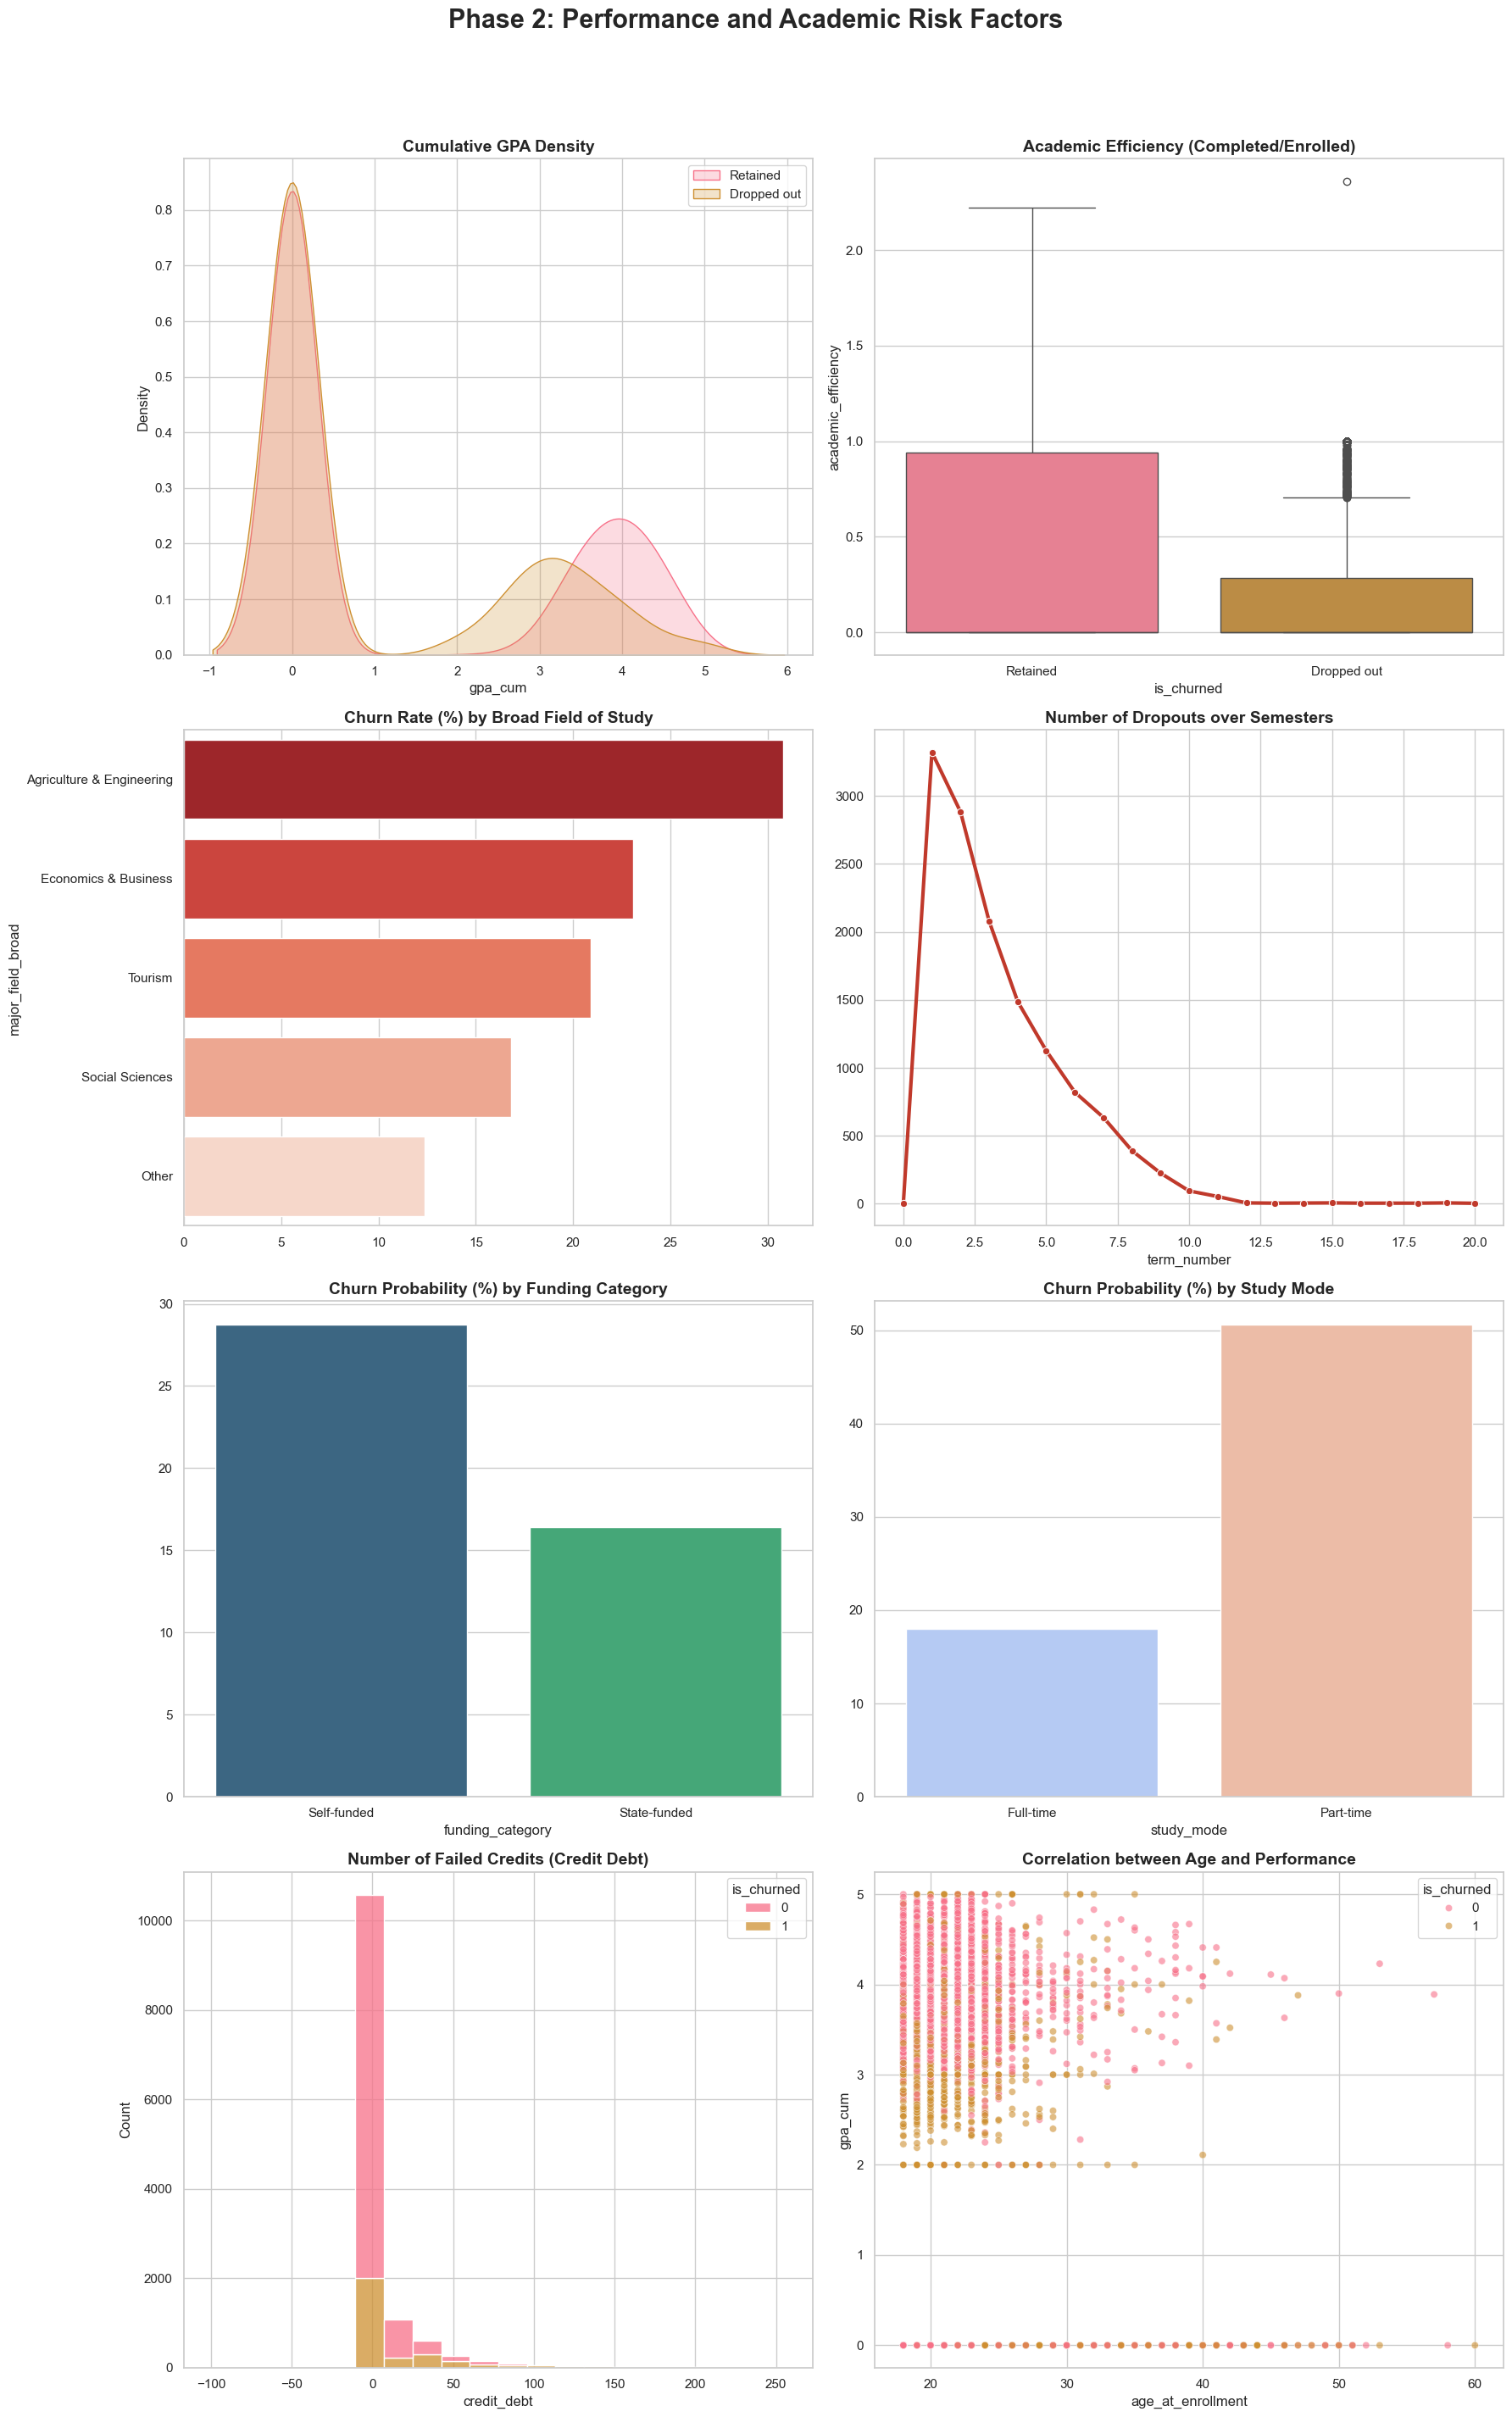

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(18, 30))
fig.suptitle('Phase 2: Performance and Academic Risk Factors', fontsize=22, fontweight='bold', y=0.98)
binary_palette = palette[:2] if 'palette' in locals() else ['#2ecc71', '#e74c3c']

sns.kdeplot(data=df_students[df_students['is_churned'] == 0], x='gpa_cum', fill=True, ax=axes[0, 0], color=binary_palette[0], label='Retained')
sns.kdeplot(data=df_students[df_students['is_churned'] == 1], x='gpa_cum', fill=True, ax=axes[0, 0], color=binary_palette[1], label='Dropped out')
axes[0, 0].set_title('Cumulative GPA Density', fontsize=14, fontweight='bold')
axes[0, 0].legend()

sns.boxplot(data=df_students, x='is_churned', y='academic_efficiency', hue='is_churned', ax=axes[0, 1], palette=binary_palette, legend=False)
axes[0, 1].set_title('Academic Efficiency (Completed/Enrolled)', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Retained', 'Dropped out'])

major_churn_val = df_students.groupby('major_field_broad')['is_churned'].mean().sort_values(ascending=False) * 100
sns.barplot(x=major_churn_val.values, y=major_churn_val.index, hue=major_churn_val.index, ax=axes[1, 0], palette='Reds_r', legend=False)
axes[1, 0].set_title('Churn Rate (%) by Broad Field of Study', fontsize=14, fontweight='bold')

churn_per_term = df[df['status_at_record'].isin(['Deleted', 'Inactive'])].groupby('term_number').size()
sns.lineplot(x=churn_per_term.index, y=churn_per_term.values, marker='o', ax=axes[1, 1], color='#c0392b', linewidth=3)
axes[1, 1].set_title('Number of Dropouts over Semesters', fontsize=14, fontweight='bold')

funding_churn = df_students.groupby('funding_category')['is_churned'].mean() * 100
sns.barplot(x=funding_churn.index, y=funding_churn.values, hue=funding_churn.index, ax=axes[2, 0], palette='viridis', legend=False)
axes[2, 0].set_title('Churn Probability (%) by Funding Category', fontsize=14, fontweight='bold')

mode_churn = df_students.groupby('study_mode')['is_churned'].mean() * 100
sns.barplot(x=mode_churn.index, y=mode_churn.values, hue=mode_churn.index, ax=axes[2, 1], palette='coolwarm', legend=False)
axes[2, 1].set_title('Churn Probability (%) by Study Mode', fontsize=14, fontweight='bold')

df_students['credit_debt'] = df_students['credits_taken_cum'] - df_students['credits_done_cum']
sns.histplot(data=df_students, x='credit_debt', hue='is_churned', bins=20, multiple="stack", ax=axes[3, 0], palette=binary_palette)
axes[3, 0].set_title('Number of Failed Credits (Credit Debt)', fontsize=14, fontweight='bold')

sns.scatterplot(data=df_students, x='age_at_enrollment', y='gpa_cum', hue='is_churned', alpha=0.6, ax=axes[3, 1], palette=binary_palette)
axes[3, 1].set_title('Correlation between Age and Performance', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 4.0 Multivariate Relationships and Correlations

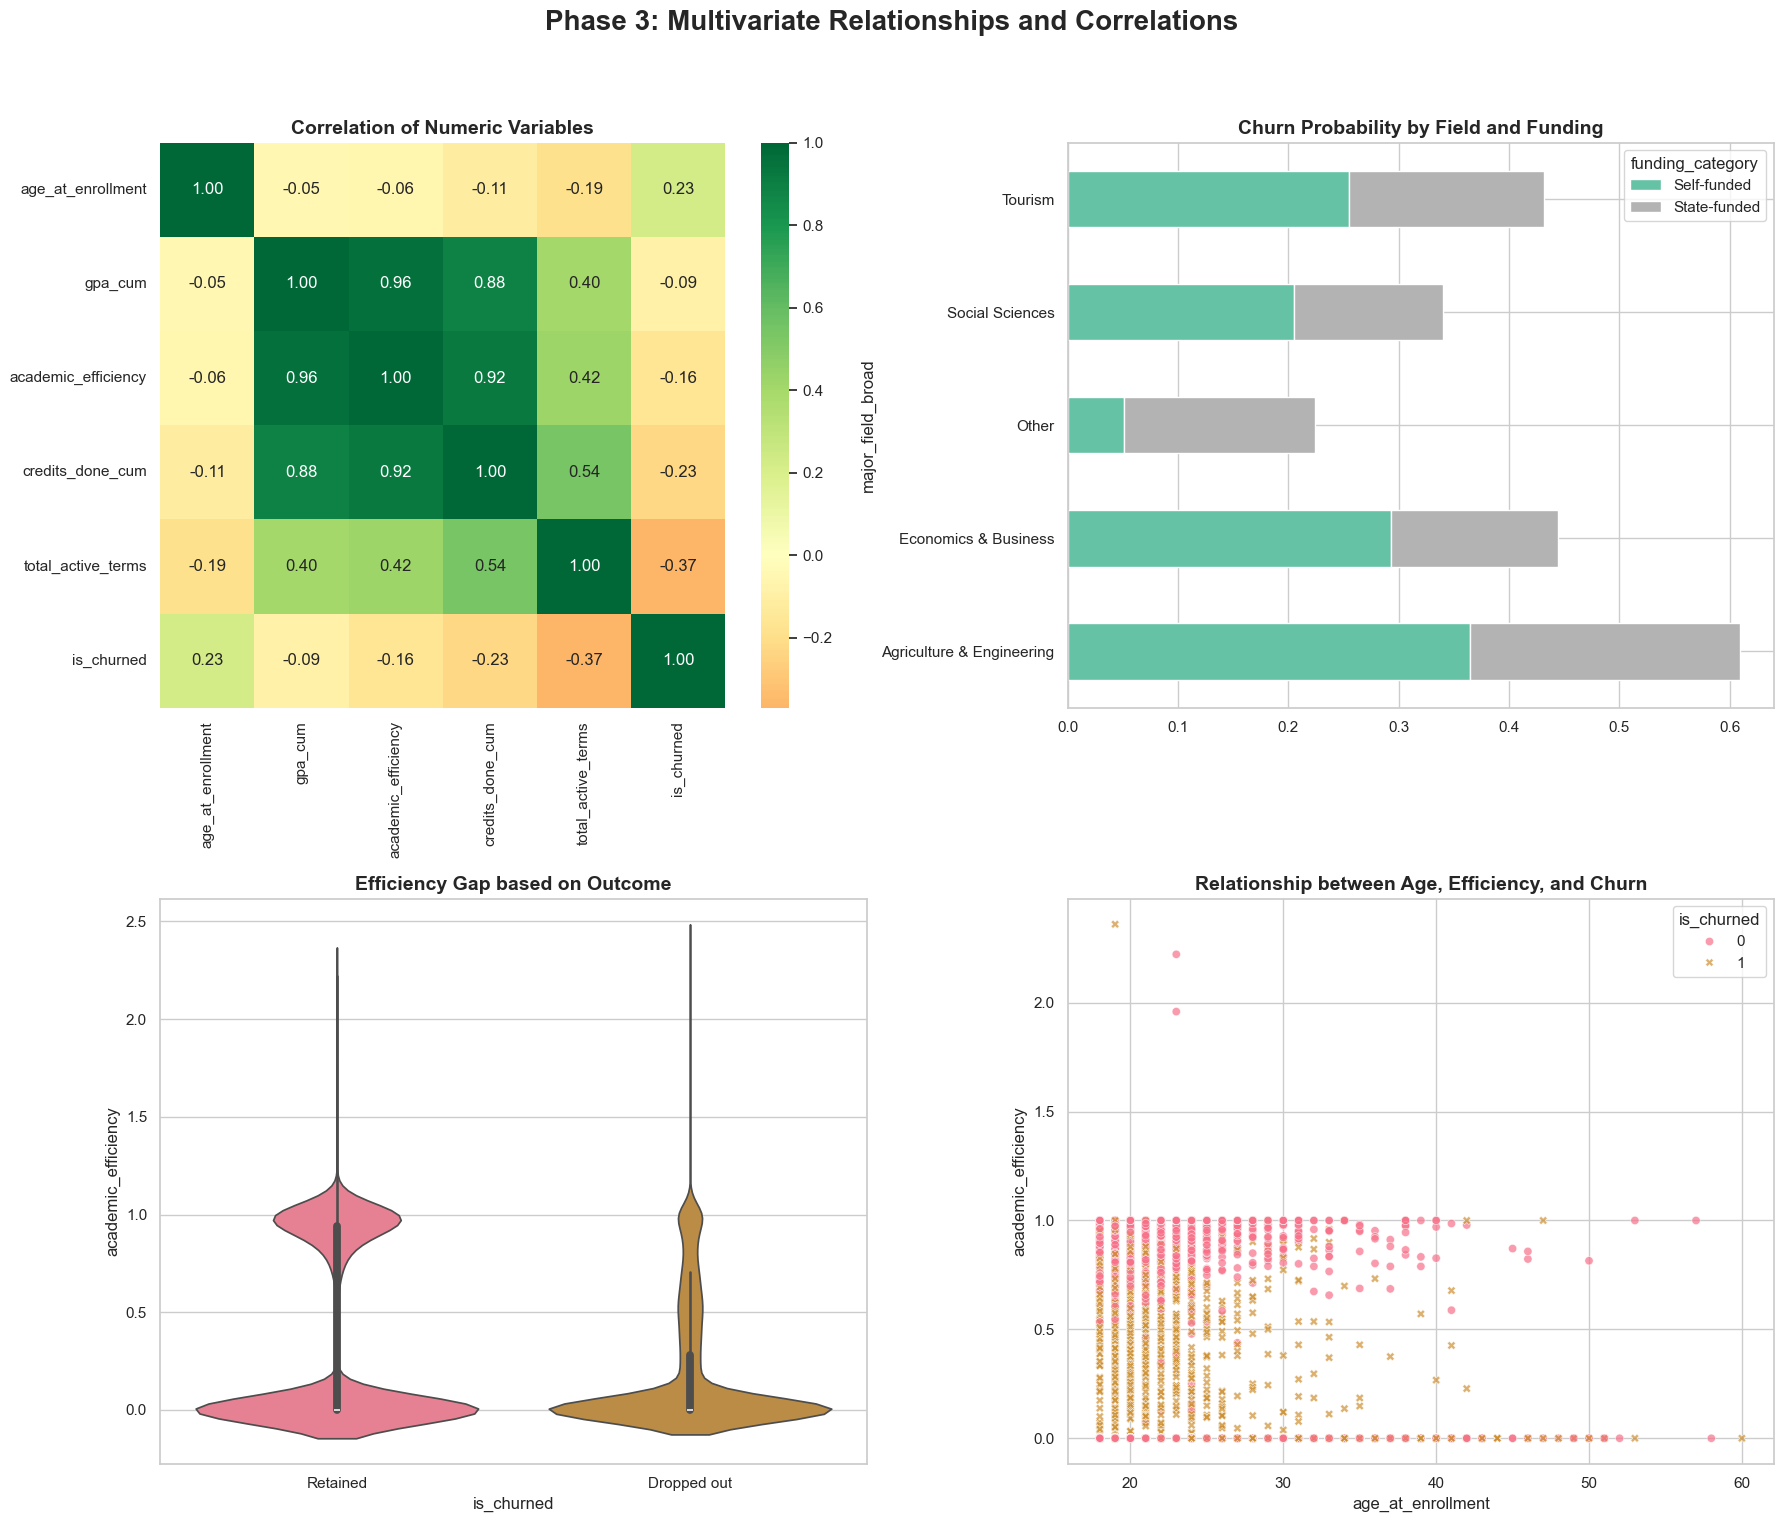

In [6]:
numeric_cols = ['age_at_enrollment', 'gpa_cum', 'academic_efficiency', 'credits_done_cum', 'total_active_terms', 'is_churned']
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
fig.suptitle('Phase 3: Multivariate Relationships and Correlations', fontsize=20, fontweight='bold')

corr = df_students[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f", ax=axes[0, 0], center=0)
axes[0, 0].set_title('Correlation of Numeric Variables', fontsize=14, fontweight='bold')

funding_major_churn = df_students.groupby(['major_field_broad', 'funding_category'])['is_churned'].mean().unstack()
funding_major_churn.plot(kind='barh', stacked=True, ax=axes[0, 1], colormap='Set2')
axes[0, 1].set_title('Churn Probability by Field and Funding', fontsize=14, fontweight='bold')

sns.violinplot(data=df_students, x='is_churned', y='academic_efficiency', hue='is_churned', ax=axes[1, 0], palette=binary_palette, legend=False)
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(['Retained', 'Dropped out'])
axes[1, 0].set_title('Efficiency Gap based on Outcome', fontsize=14, fontweight='bold')

sns.scatterplot(data=df_students, x='age_at_enrollment', y='academic_efficiency', hue='is_churned', style='is_churned', palette=binary_palette, alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title('Relationship between Age, Efficiency, and Churn', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 5.0 Advanced Segmentation and Interaction Analysis

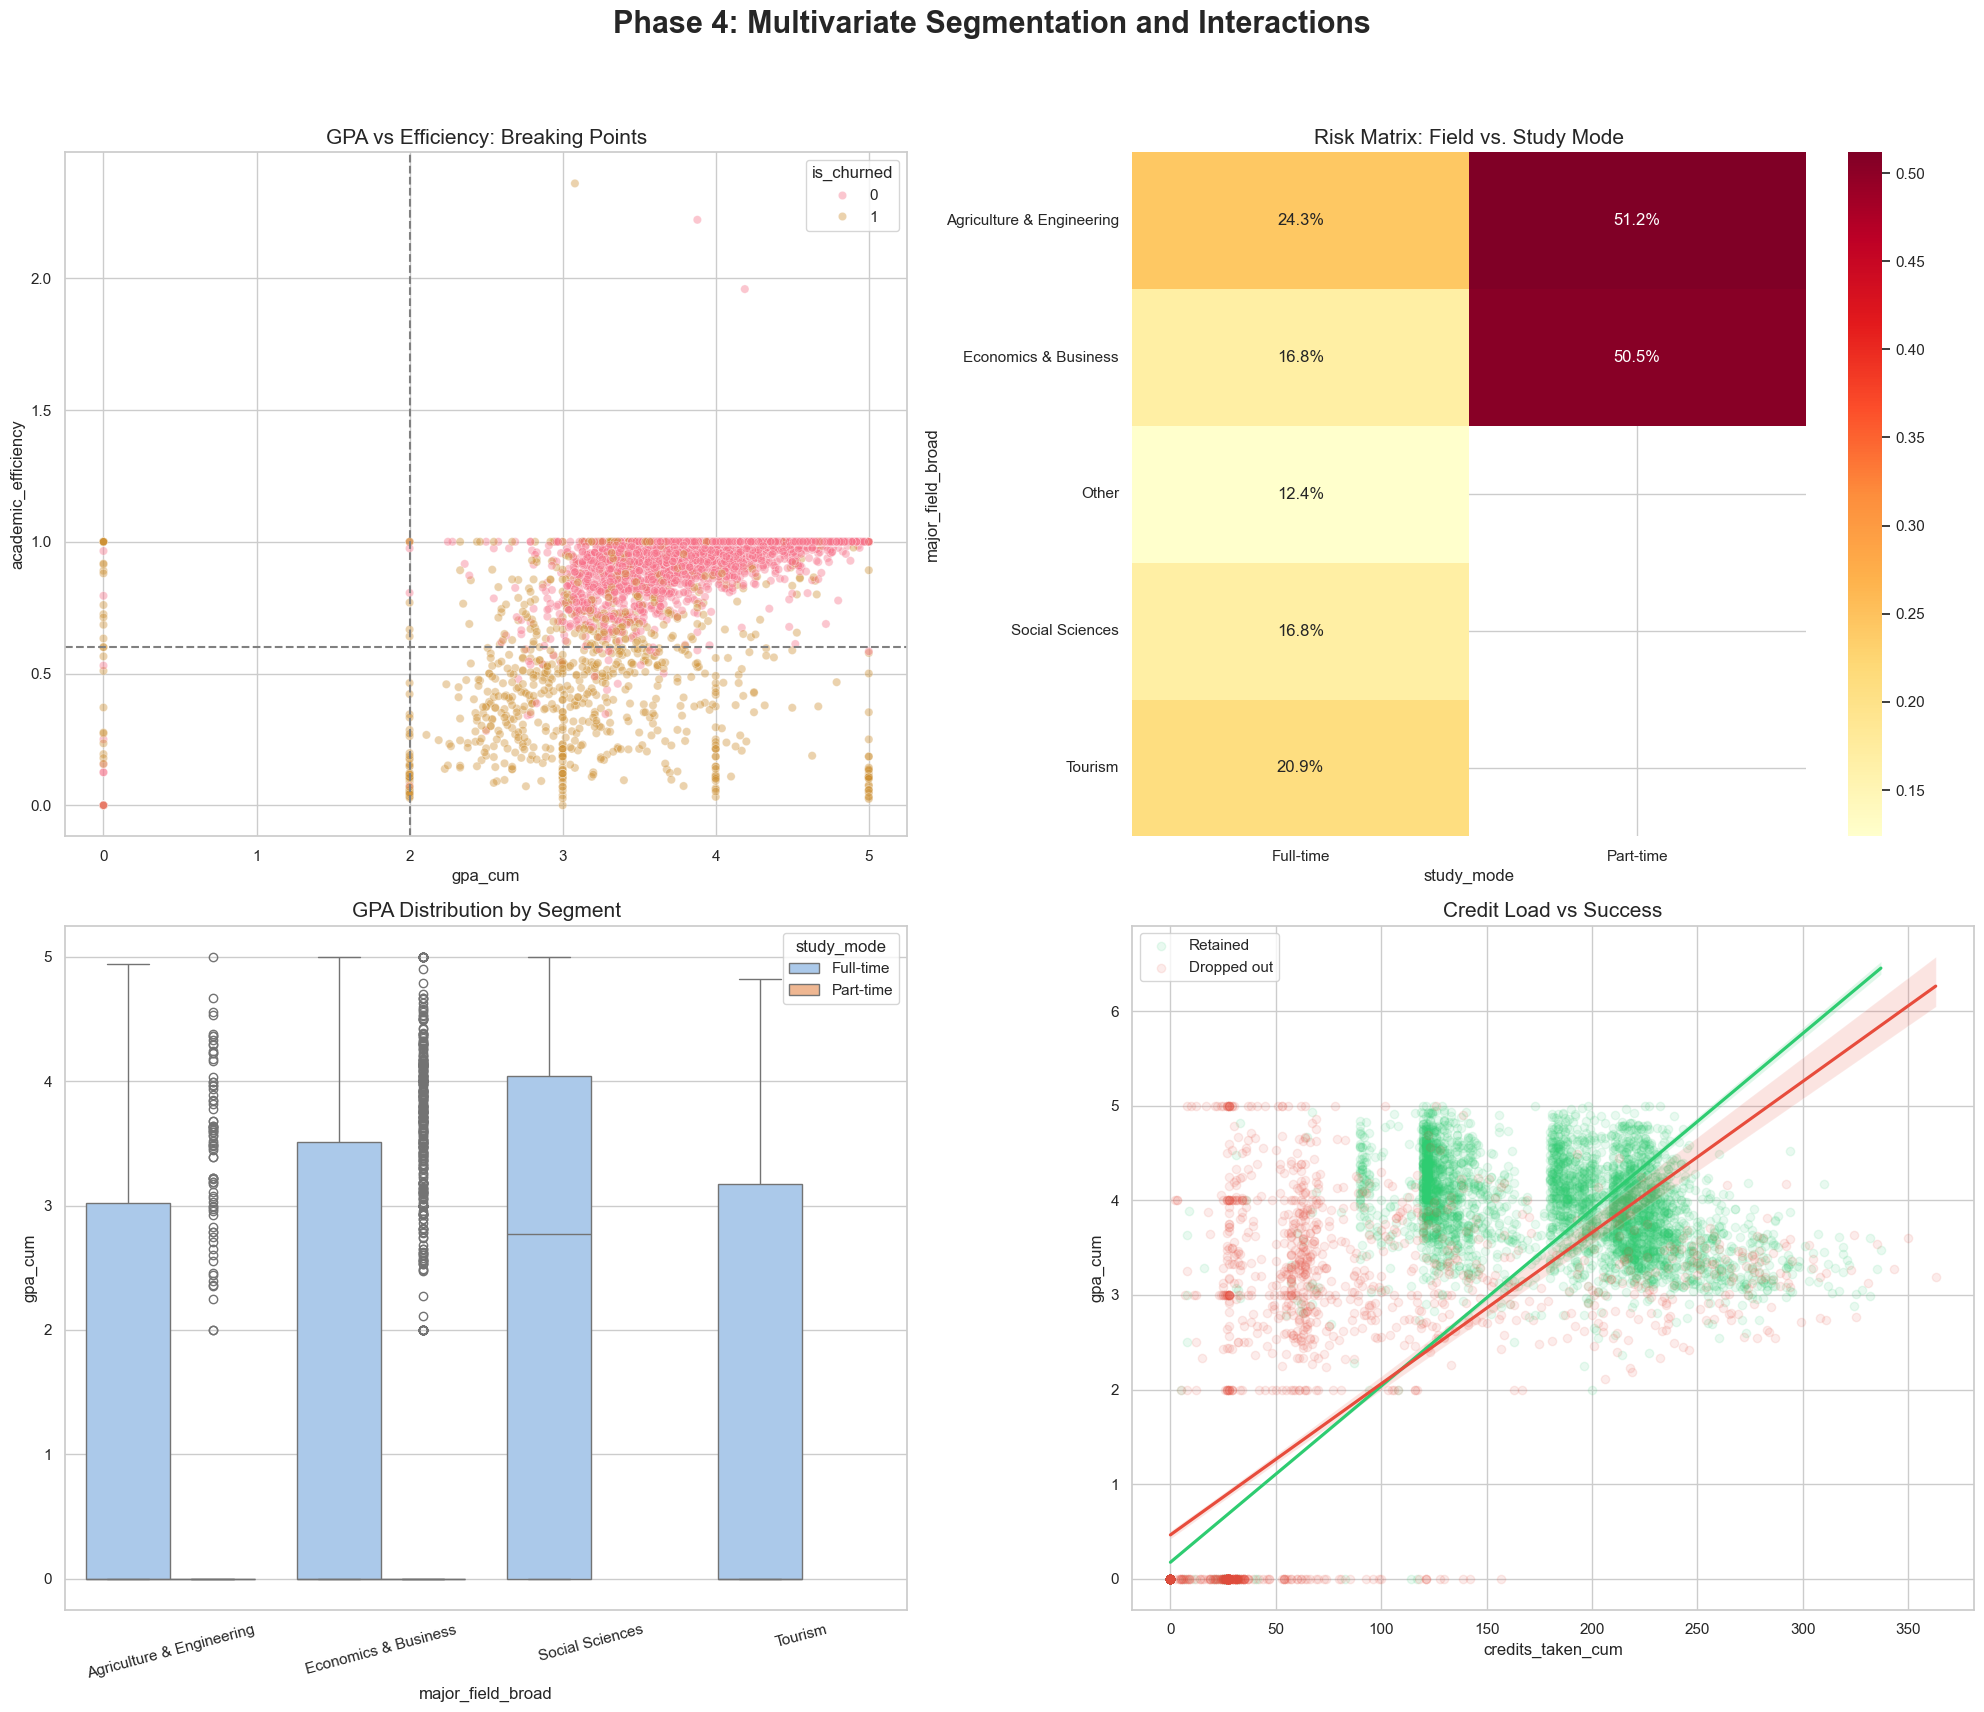

In [7]:
top_fields = df_students['major_field_broad'].value_counts().nlargest(4).index
df_sub = df_students[df_students['major_field_broad'].isin(top_fields)]

fig, axes = plt.subplots(2, 2, figsize=(20, 18))
fig.suptitle('Phase 4: Multivariate Segmentation and Interactions', fontsize=22, fontweight='bold', y=0.98)

sns.scatterplot(data=df_students, x='gpa_cum', y='academic_efficiency', hue='is_churned', alpha=0.4, palette=binary_palette, ax=axes[0, 0])
axes[0, 0].axvline(x=2.0, color='grey', linestyle='--')
axes[0, 0].axhline(y=0.6, color='grey', linestyle='--')
axes[0, 0].set_title('GPA vs Efficiency: Breaking Points', fontsize=15)

pivot_risk = df_students.pivot_table(index='major_field_broad', columns='study_mode', values='is_churned', aggfunc='mean')
sns.heatmap(pivot_risk, annot=True, fmt=".1%", cmap='YlOrRd', ax=axes[0, 1])
axes[0, 1].set_title('Risk Matrix: Field vs. Study Mode', fontsize=15)

sns.boxplot(data=df_sub, x='major_field_broad', y='gpa_cum', hue='study_mode', ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('GPA Distribution by Segment', fontsize=15)
axes[1, 0].tick_params(axis='x', rotation=15)

sns.regplot(data=df_students[df_students['is_churned']==0], x='credits_taken_cum', y='gpa_cum', scatter_kws={'alpha':0.1}, label='Retained', color='#2ecc71', ax=axes[1, 1])
sns.regplot(data=df_students[df_students['is_churned']==1], x='credits_taken_cum', y='gpa_cum', scatter_kws={'alpha':0.1}, label='Dropped out', color='#e74c3c', ax=axes[1, 1])
axes[1, 1].legend()
axes[1, 1].set_title('Credit Load vs Success', fontsize=15)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 6.0 Longitudinal Dynamic and Survival Analysis

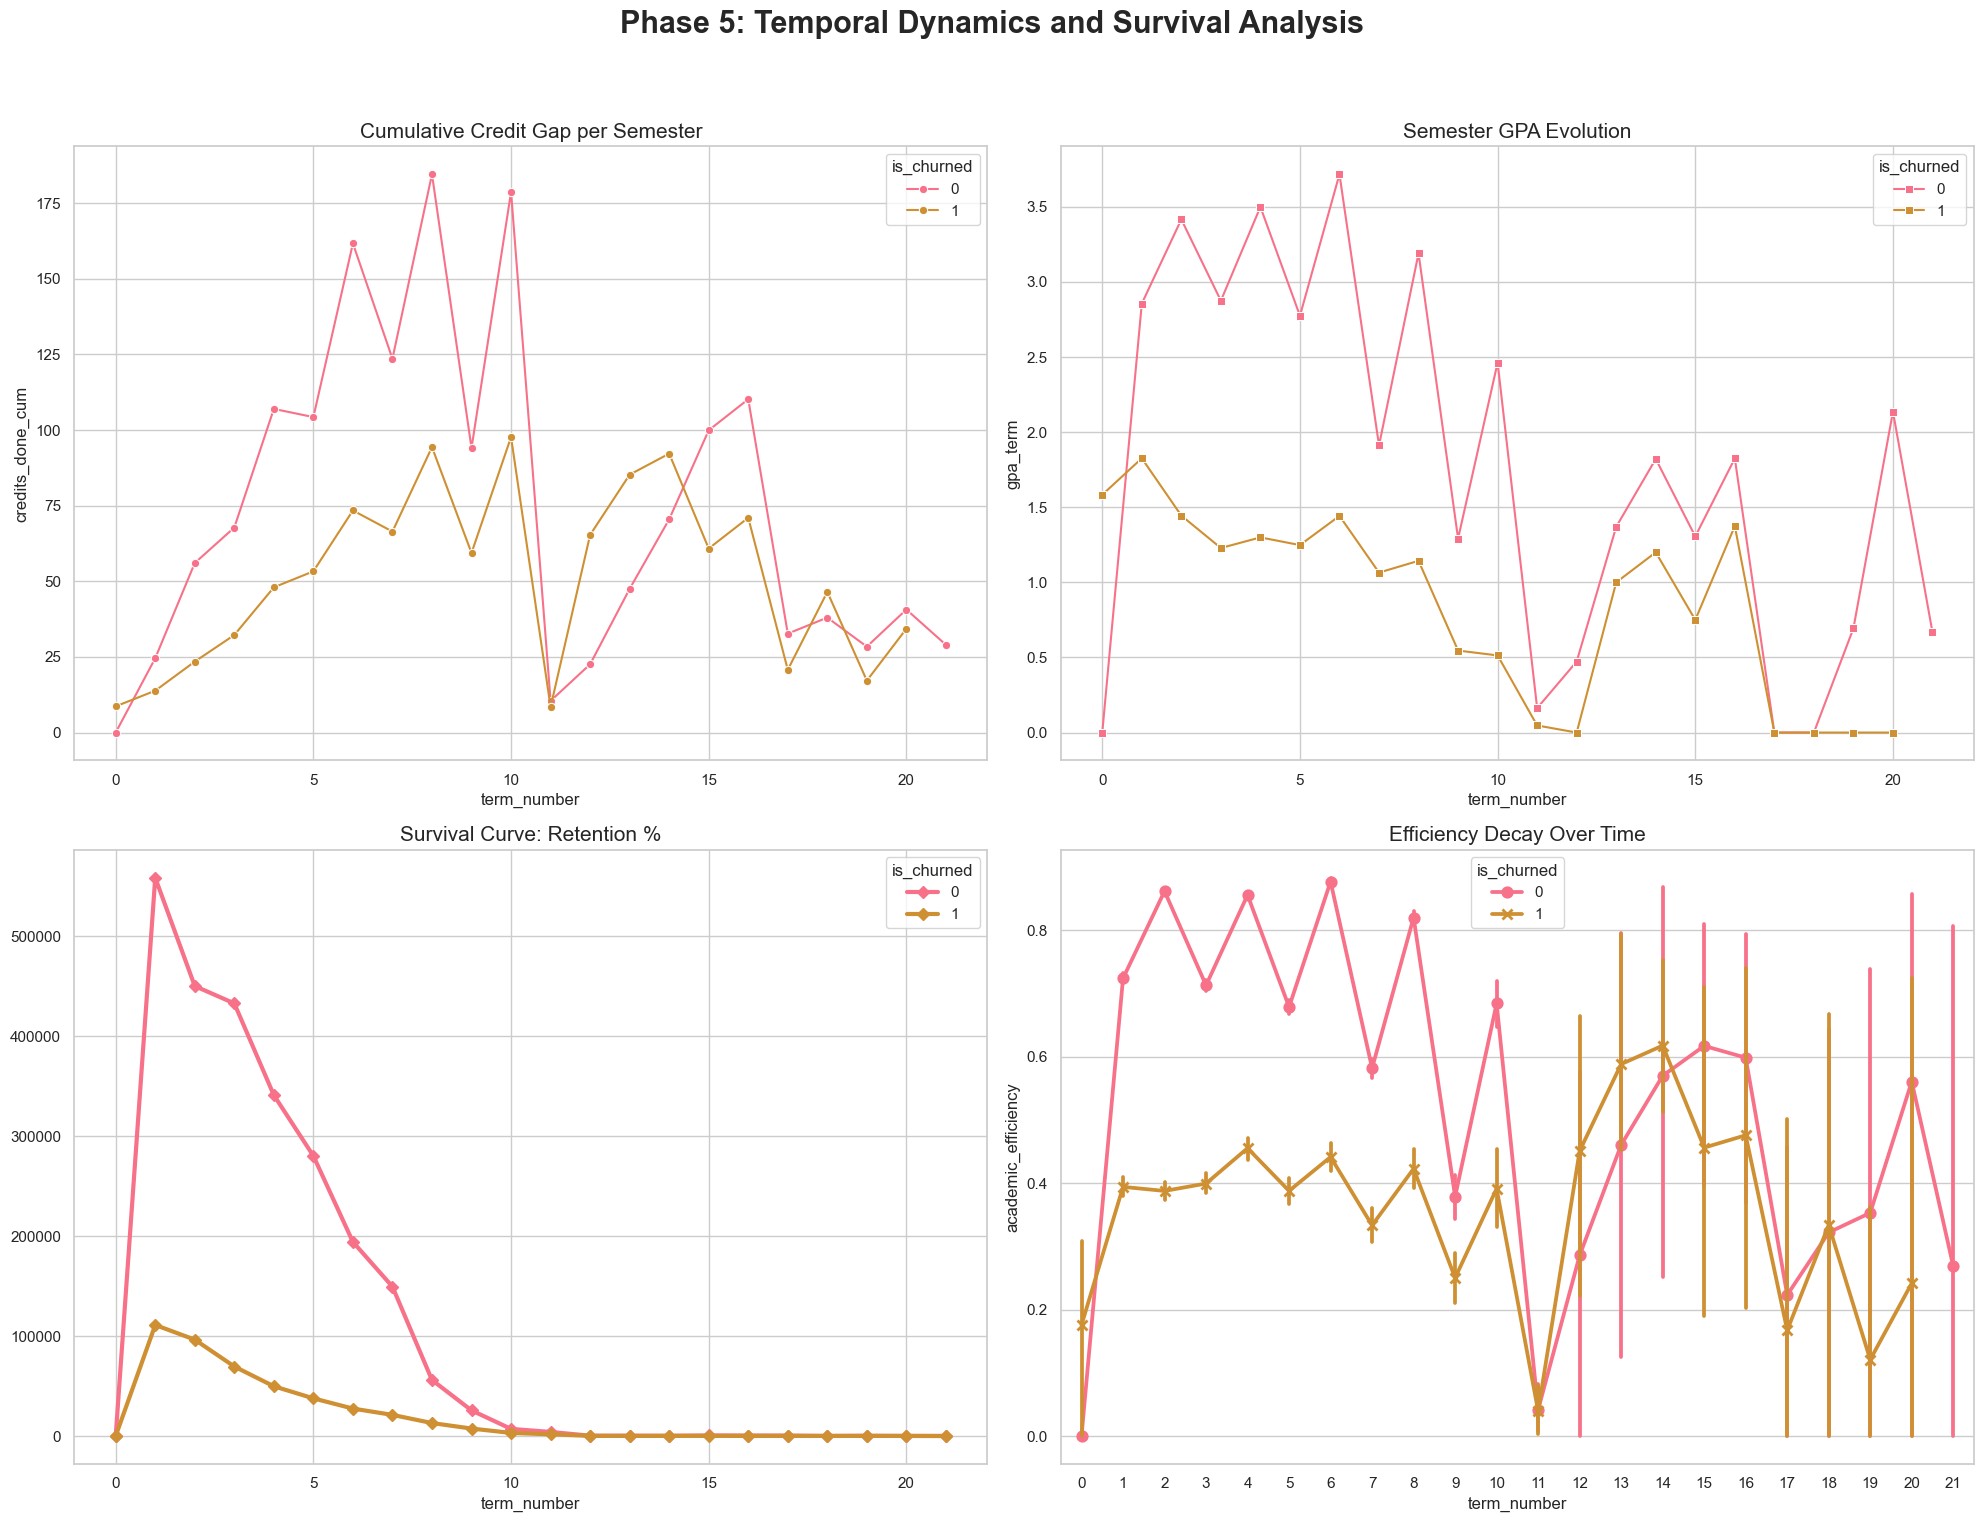

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Phase 5: Temporal Dynamics and Survival Analysis', fontsize=22, fontweight='bold', y=0.98)

sns.lineplot(data=df, x='term_number', y='credits_done_cum', hue='is_churned', marker='o', palette=binary_palette, ax=axes[0, 0], errorbar=None)
axes[0, 0].set_title('Cumulative Credit Gap per Semester', fontsize=15)

sns.lineplot(data=df, x='term_number', y='gpa_term', hue='is_churned', marker='s', palette=binary_palette, ax=axes[0, 1], errorbar=None)
axes[0, 1].set_title('Semester GPA Evolution', fontsize=15)

retention = df.groupby(['term_number', 'is_churned']).size().unstack().fillna(0)
retention_pct = retention.divide(retention.iloc[0], axis=1) * 100
retention_pct.plot(kind='line', marker='D', ax=axes[1, 0], color=binary_palette, linewidth=3)
axes[1, 0].set_title('Survival Curve: Retention %', fontsize=15)

sns.pointplot(data=df, x='term_number', y='academic_efficiency', hue='is_churned', palette=binary_palette, ax=axes[1, 1], markers=["o", "x"])
axes[1, 1].set_title('Efficiency Decay Over Time', fontsize=15)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()